원본: /home/harry/Re_leaf_Project/Inpainting/original/Tomato Early Blight1.jpg
마스크: /home/harry/Re_leaf_Project/Inpainting/mask/Tomato Early Blight1.png
저장: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_patch_restored.png
image shape: (1572, 1147, 3)
mask shape: (1572, 1147)
mask bbox: 140 171 554 1234
padded bbox: 120 151 574 1254
patch size: 454 1103
best score: 25.87942427578167
best patch position: (312, 0)


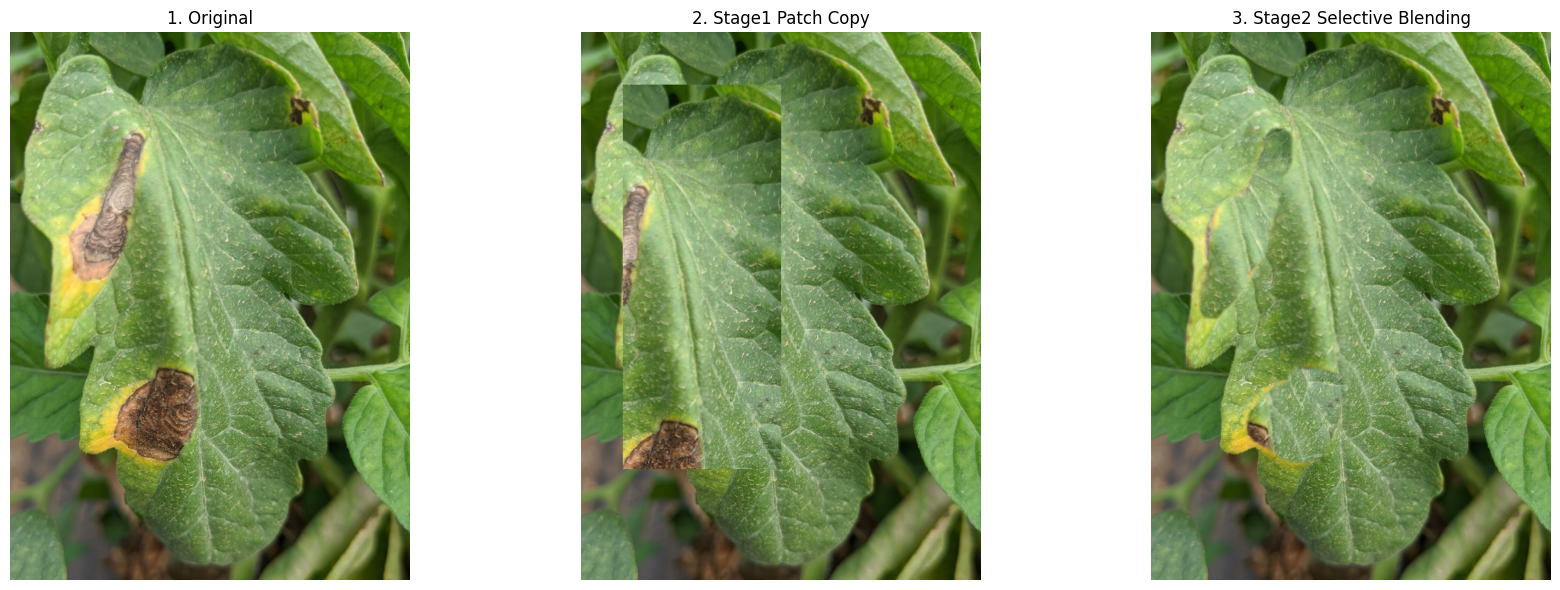

저장 완료: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_patch_restored.png


In [3]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# 0. 경로 설정
# =========================

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(BASE_DIR, "original", "Tomato Early Blight1.jpg")
MASK_PATH = os.path.join(BASE_DIR, "mask", "Tomato Early Blight1.png")

OUTPUT_DIR = os.path.join(BASE_DIR, "patch_restoration_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH = os.path.join(OUTPUT_DIR, "early_blight1_patch_restored.png")

print("원본:", ORIGINAL_PATH)
print("마스크:", MASK_PATH)
print("저장:", SAVE_PATH)


# =========================
# 1. 이미지 로드
# =========================

image_bgr = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)

_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

print("image shape:", image.shape)
print("mask shape:", mask_bin.shape)


# =========================
# 2. 마스크 영역 bounding box 추출
# =========================

ys, xs = np.where(mask_bin > 0)

x1, x2 = xs.min(), xs.max()
y1, y2 = ys.min(), ys.max()

# 여유 padding
pad = 20
h, w = image.shape[:2]

x1p = max(0, x1 - pad)
y1p = max(0, y1 - pad)
x2p = min(w, x2 + pad)
y2p = min(h, y2 + pad)

target_w = x2p - x1p
target_h = y2p - y1p

print("mask bbox:", x1, y1, x2, y2)
print("padded bbox:", x1p, y1p, x2p, y2p)
print("patch size:", target_w, target_h)


# =========================
# 3. 후보 healthy patch 탐색 - 완화 버전
# =========================

best_score = float("inf")
best_patch = None
best_pos = None

target_region = image[y1p:y2p, x1p:x2p]
target_mask = mask_bin[y1p:y2p, x1p:x2p]

healthy_pixels_near = target_region[target_mask == 0]
target_mean = healthy_pixels_near.mean(axis=0)

step = 12

for yy in range(0, h - target_h, step):
    for xx in range(0, w - target_w, step):

        candidate_mask = mask_bin[yy:yy+target_h, xx:xx+target_w]

        # 후보 patch 안에 병반 mask가 10% 이상이면 제외
        mask_ratio = np.mean(candidate_mask > 0)
        if mask_ratio > 0.10:
            continue

        candidate = image[yy:yy+target_h, xx:xx+target_w]

        candidate_mean = candidate.reshape(-1, 3).mean(axis=0)
        color_score = np.linalg.norm(candidate_mean - target_mean)

        target_gray = cv2.cvtColor(target_region, cv2.COLOR_RGB2GRAY)
        cand_gray = cv2.cvtColor(candidate, cv2.COLOR_RGB2GRAY)

        target_grad = cv2.Laplacian(target_gray, cv2.CV_64F).var()
        cand_grad = cv2.Laplacian(cand_gray, cv2.CV_64F).var()

        texture_score = abs(target_grad - cand_grad)

        score = color_score + 0.03 * texture_score

        if score < best_score:
            best_score = score
            best_patch = candidate.copy()
            best_pos = (xx, yy)

print("best score:", best_score)
print("best patch position:", best_pos)

if best_patch is None:
    raise ValueError("후보 patch를 못 찾았습니다. mask를 줄이거나 target bbox를 병반별로 나눠야 합니다.")

# =========================
# 4. Poisson blending 적용
# =========================
restored = image.copy()

# 병반 영역 crop
target_crop = restored[y1p:y2p, x1p:x2p]

# 병반 mask
mask_crop = target_mask.copy()

# patch resize
patch_resized = cv2.resize(best_patch, (target_w, target_h))

# feather mask
mask_float = mask_crop.astype(np.float32) / 255.0
mask_float = cv2.GaussianBlur(mask_float, (21, 21), 0)

mask_float = np.expand_dims(mask_float, axis=-1)

# selective blending
blended_crop = (
    patch_resized * mask_float +
    target_crop * (1.0 - mask_float)
).astype(np.uint8)

# 원본에 삽입
restored[y1p:y2p, x1p:x2p] = blended_crop

# =========================
# 5. 비교 시각화
# =========================
stage1 = Image.open(os.path.join(OUTPUT_DIR, "early_blight1_patch_restored.png")).convert("RGB")
stage1 = np.array(stage1)
stage1 = image.copy()
stage1[y1p:y2p, x1p:x2p] = patch_resized

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stage1)
plt.title("2. Stage1 Patch Copy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(restored)
plt.title("3. Stage2 Selective Blending")
plt.axis("off")

plt.tight_layout()
plt.show()

Image.fromarray(restored).save(SAVE_PATH)
print("저장 완료:", SAVE_PATH)

원본: /home/harry/Re_leaf_Project/Inpainting/original/Tomato Early Blight1.jpg
마스크: /home/harry/Re_leaf_Project/Inpainting/mask/Tomato Early Blight1.png
저장: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_patch_restored_rotation.png
image shape: (1572, 1147, 3)
mask shape: (1572, 1147)
padded bbox: 120 151 574 1254
patch size: 454 1103
best score: 27.0920542822139
best patch position: (312, 0)
best rotation: 180


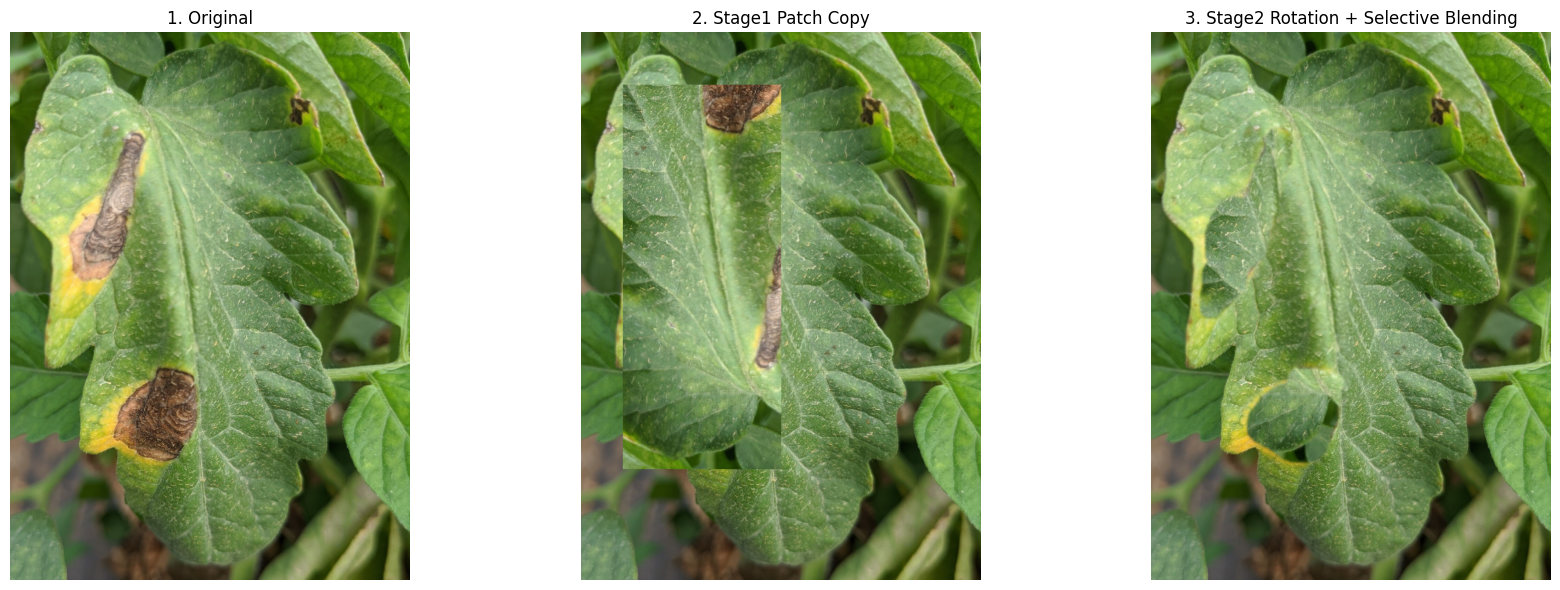

저장 완료: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_patch_restored_rotation.png


In [4]:
# =========================
# 0. 경로 설정
# =========================

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(BASE_DIR, "original", "Tomato Early Blight1.jpg")
MASK_PATH = os.path.join(BASE_DIR, "mask", "Tomato Early Blight1.png")

OUTPUT_DIR = os.path.join(BASE_DIR, "patch_restoration_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH = os.path.join(OUTPUT_DIR, "early_blight1_patch_restored_rotation.png")

print("원본:", ORIGINAL_PATH)
print("마스크:", MASK_PATH)
print("저장:", SAVE_PATH)

# =========================
# 1. 이미지 로드
# =========================

image_bgr = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

h, w = image.shape[:2]

print("image shape:", image.shape)
print("mask shape:", mask_bin.shape)

# =========================
# 2. 전체 마스크 bbox 추출
# =========================

ys, xs = np.where(mask_bin > 0)

x1, x2 = xs.min(), xs.max()
y1, y2 = ys.min(), ys.max()

pad = 20

x1p = max(0, x1 - pad)
y1p = max(0, y1 - pad)
x2p = min(w, x2 + pad)
y2p = min(h, y2 + pad)

target_w = x2p - x1p
target_h = y2p - y1p

target_region = image[y1p:y2p, x1p:x2p]
target_mask = mask_bin[y1p:y2p, x1p:x2p]

healthy_pixels_near = target_region[target_mask == 0]

if len(healthy_pixels_near) == 0:
    raise ValueError("target 주변 healthy pixel이 없습니다. mask를 줄여야 합니다.")

target_mean = healthy_pixels_near.mean(axis=0)
target_gray = cv2.cvtColor(target_region, cv2.COLOR_RGB2GRAY)

gx_t = cv2.Sobel(target_gray, cv2.CV_64F, 1, 0, ksize=3)
gy_t = cv2.Sobel(target_gray, cv2.CV_64F, 0, 1, ksize=3)
angle_t = np.mean(np.arctan2(gy_t, gx_t))
target_grad = cv2.Laplacian(target_gray, cv2.CV_64F).var()

print("padded bbox:", x1p, y1p, x2p, y2p)
print("patch size:", target_w, target_h)

# =========================
# 3. Rotation-aware healthy patch 탐색
# =========================

best_score = float("inf")
best_patch = None
best_pos = None
best_rotation = None

step = 12

for yy in range(0, h - target_h, step):
    for xx in range(0, w - target_w, step):

        candidate_mask = mask_bin[yy:yy+target_h, xx:xx+target_w]

        mask_ratio = np.mean(candidate_mask > 0)
        if mask_ratio > 0.10:
            continue

        candidate_base = image[yy:yy+target_h, xx:xx+target_w]

        rotations = [
            ("0", candidate_base),
            ("90", cv2.rotate(candidate_base, cv2.ROTATE_90_CLOCKWISE)),
            ("180", cv2.rotate(candidate_base, cv2.ROTATE_180)),
            ("270", cv2.rotate(candidate_base, cv2.ROTATE_90_COUNTERCLOCKWISE)),
        ]

        for rot_name, candidate in rotations:
            candidate = cv2.resize(candidate, (target_w, target_h))

            candidate_mean = candidate.reshape(-1, 3).mean(axis=0)
            color_score = np.linalg.norm(candidate_mean - target_mean)

            cand_gray = cv2.cvtColor(candidate, cv2.COLOR_RGB2GRAY)
            cand_grad = cv2.Laplacian(cand_gray, cv2.CV_64F).var()
            texture_score = abs(target_grad - cand_grad)

            gx_c = cv2.Sobel(cand_gray, cv2.CV_64F, 1, 0, ksize=3)
            gy_c = cv2.Sobel(cand_gray, cv2.CV_64F, 0, 1, ksize=3)
            angle_c = np.mean(np.arctan2(gy_c, gx_c))

            orientation_score = abs(angle_t - angle_c)

            score = (
                color_score
                + 0.03 * texture_score
                + 25.0 * orientation_score
            )

            if score < best_score:
                best_score = score
                best_patch = candidate.copy()
                best_pos = (xx, yy)
                best_rotation = rot_name

if best_patch is None:
    raise ValueError("후보 patch를 못 찾았습니다. mask를 줄이거나 병반별로 나눠야 합니다.")

print("best score:", best_score)
print("best patch position:", best_pos)
print("best rotation:", best_rotation)

# =========================
# 4. Stage1: 단순 patch copy
# =========================

stage1 = image.copy()
patch_resized = cv2.resize(best_patch, (target_w, target_h))
stage1[y1p:y2p, x1p:x2p] = patch_resized

# =========================
# 5. Stage2: Selective blending
# =========================

restored = image.copy()

target_crop = restored[y1p:y2p, x1p:x2p]
mask_crop = target_mask.copy()

mask_float = mask_crop.astype(np.float32) / 255.0
mask_float = cv2.GaussianBlur(mask_float, (21, 21), 0)
mask_float = np.expand_dims(mask_float, axis=-1)

blended_crop = (
    patch_resized * mask_float +
    target_crop * (1.0 - mask_float)
).astype(np.uint8)

restored[y1p:y2p, x1p:x2p] = blended_crop

# =========================
# 6. 비교 시각화
# =========================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stage1)
plt.title("2. Stage1 Patch Copy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(restored)
plt.title("3. Stage2 Rotation + Selective Blending")
plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# 7. 저장
# =========================

Image.fromarray(restored).save(SAVE_PATH)
print("저장 완료:", SAVE_PATH)

병반 덩어리 개수: 2
component 1 | bbox=(np.int32(124), np.int32(260), np.int32(421), np.int32(836)) | best_pos=(350, 300) | rotation=90 | score=12.40
component 2 | bbox=(np.int32(259), np.int32(948), np.int32(571), np.int32(1251)) | best_pos=(510, 800) | rotation=180 | score=29.55


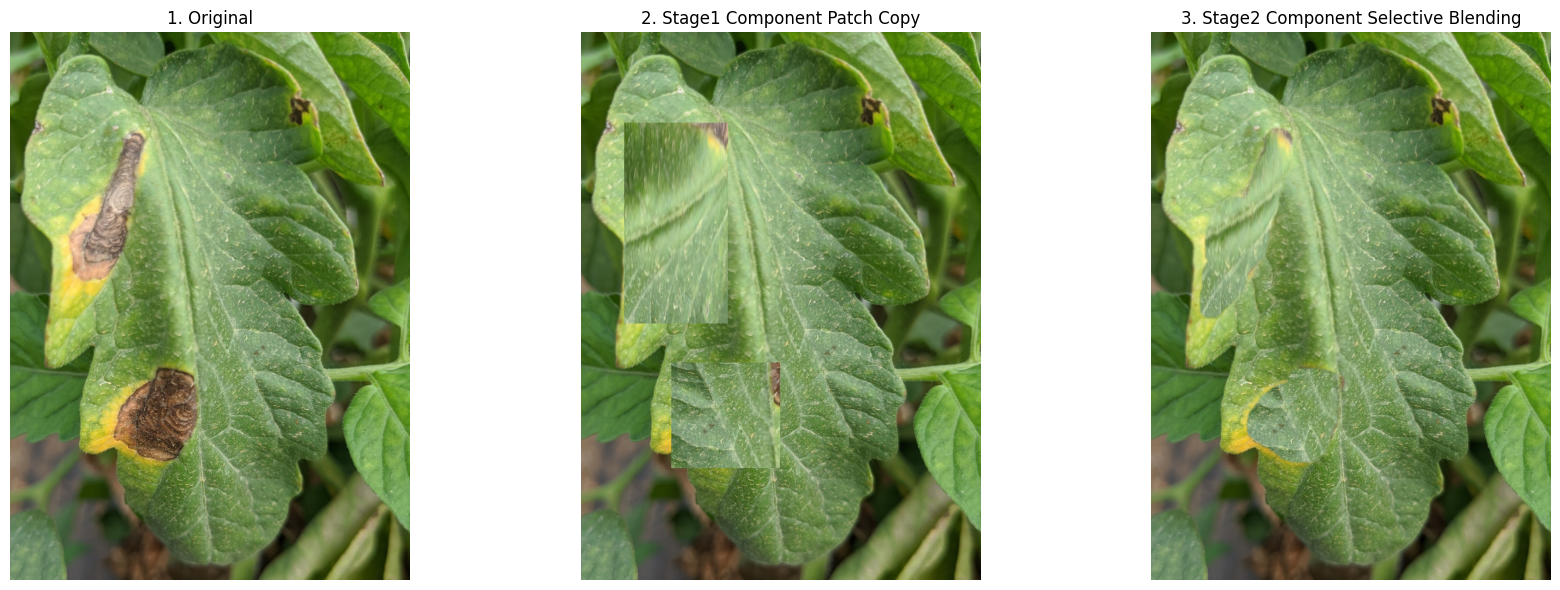

저장 완료: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_component_restored.png


In [5]:
# =========================
# 0. 경로 설정
# =========================

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(BASE_DIR, "original", "Tomato Early Blight1.jpg")
MASK_PATH = os.path.join(BASE_DIR, "mask", "Tomato Early Blight1.png")

OUTPUT_DIR = os.path.join(BASE_DIR, "patch_restoration_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH = os.path.join(OUTPUT_DIR, "early_blight1_component_restored.png")

# =========================
# 1. 이미지 로드
# =========================

image_bgr = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

h, w = image.shape[:2]

# =========================
# 2. 병반 덩어리 분리
# =========================

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)

components = []

MIN_AREA = 30

for label_id in range(1, num_labels):
    x, y, bw, bh, area = stats[label_id]

    if area < MIN_AREA:
        continue

    components.append({
        "label_id": label_id,
        "x": x,
        "y": y,
        "w": bw,
        "h": bh,
        "area": area
    })

print("병반 덩어리 개수:", len(components))

# =========================
# 3. 단일 component 복원 함수
# =========================

def find_best_patch_for_component(image, mask_bin, comp, pad=16, step=10):
    h, w = image.shape[:2]

    x, y, bw, bh = comp["x"], comp["y"], comp["w"], comp["h"]

    x1p = max(0, x - pad)
    y1p = max(0, y - pad)
    x2p = min(w, x + bw + pad)
    y2p = min(h, y + bh + pad)

    target_w = x2p - x1p
    target_h = y2p - y1p

    target_region = image[y1p:y2p, x1p:x2p]
    target_mask = mask_bin[y1p:y2p, x1p:x2p]

    healthy_pixels_near = target_region[target_mask == 0]

    if len(healthy_pixels_near) == 0:
        return None

    target_mean = healthy_pixels_near.mean(axis=0)
    target_gray = cv2.cvtColor(target_region, cv2.COLOR_RGB2GRAY)

    gx_t = cv2.Sobel(target_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy_t = cv2.Sobel(target_gray, cv2.CV_64F, 0, 1, ksize=3)
    angle_t = np.mean(np.arctan2(gy_t, gx_t))
    target_grad = cv2.Laplacian(target_gray, cv2.CV_64F).var()

    best_score = float("inf")
    best_patch = None
    best_pos = None
    best_rotation = None

    for yy in range(0, h - target_h, step):
        for xx in range(0, w - target_w, step):

            candidate_mask = mask_bin[yy:yy+target_h, xx:xx+target_w]
            mask_ratio = np.mean(candidate_mask > 0)

            if mask_ratio > 0.05:
                continue

            candidate_base = image[yy:yy+target_h, xx:xx+target_w]

            rotations = [
                ("0", candidate_base),
                ("90", cv2.rotate(candidate_base, cv2.ROTATE_90_CLOCKWISE)),
                ("180", cv2.rotate(candidate_base, cv2.ROTATE_180)),
                ("270", cv2.rotate(candidate_base, cv2.ROTATE_90_COUNTERCLOCKWISE)),
            ]

            for rot_name, candidate in rotations:
                candidate = cv2.resize(candidate, (target_w, target_h))

                candidate_mean = candidate.reshape(-1, 3).mean(axis=0)
                color_score = np.linalg.norm(candidate_mean - target_mean)

                cand_gray = cv2.cvtColor(candidate, cv2.COLOR_RGB2GRAY)
                cand_grad = cv2.Laplacian(cand_gray, cv2.CV_64F).var()
                texture_score = abs(target_grad - cand_grad)

                gx_c = cv2.Sobel(cand_gray, cv2.CV_64F, 1, 0, ksize=3)
                gy_c = cv2.Sobel(cand_gray, cv2.CV_64F, 0, 1, ksize=3)
                angle_c = np.mean(np.arctan2(gy_c, gx_c))

                orientation_score = abs(angle_t - angle_c)

                score = (
                    color_score
                    + 0.03 * texture_score
                    + 25.0 * orientation_score
                )

                if score < best_score:
                    best_score = score
                    best_patch = candidate.copy()
                    best_pos = (xx, yy)
                    best_rotation = rot_name

    if best_patch is None:
        return None

    return {
        "bbox": (x1p, y1p, x2p, y2p),
        "patch": best_patch,
        "pos": best_pos,
        "rotation": best_rotation,
        "score": best_score
    }

# =========================
# 4. Component별 복원
# =========================

stage1 = image.copy()
stage2 = image.copy()

logs = []

for idx, comp in enumerate(components, start=1):
    result = find_best_patch_for_component(image, mask_bin, comp, pad=16, step=10)

    if result is None:
        print(f"[{idx}] patch 못 찾음. skip")
        continue

    x1p, y1p, x2p, y2p = result["bbox"]
    target_w = x2p - x1p
    target_h = y2p - y1p

    patch_resized = cv2.resize(result["patch"], (target_w, target_h))

    target_crop_stage1 = stage1[y1p:y2p, x1p:x2p]
    target_crop_stage2 = stage2[y1p:y2p, x1p:x2p]

    mask_crop = mask_bin[y1p:y2p, x1p:x2p]

    # Stage1: component bbox에 patch 직접 복사
    stage1[y1p:y2p, x1p:x2p] = patch_resized

    # Stage2: mask 내부만 selective blending
    mask_float = mask_crop.astype(np.float32) / 255.0
    mask_float = cv2.GaussianBlur(mask_float, (15, 15), 0)
    mask_float = np.expand_dims(mask_float, axis=-1)

    blended_crop = (
        patch_resized * mask_float +
        target_crop_stage2 * (1.0 - mask_float)
    ).astype(np.uint8)

    stage2[y1p:y2p, x1p:x2p] = blended_crop

    logs.append({
        "component": idx,
        "bbox": result["bbox"],
        "best_pos": result["pos"],
        "rotation": result["rotation"],
        "score": result["score"]
    })

for log in logs:
    print(
        f"component {log['component']} | "
        f"bbox={log['bbox']} | "
        f"best_pos={log['best_pos']} | "
        f"rotation={log['rotation']} | "
        f"score={log['score']:.2f}"
    )

# =========================
# 5. 비교 시각화
# =========================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stage1)
plt.title("2. Stage1 Component Patch Copy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(stage2)
plt.title("3. Stage2 Component Selective Blending")
plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# 6. 저장
# =========================

Image.fromarray(stage2).save(SAVE_PATH)
print("저장 완료:", SAVE_PATH)

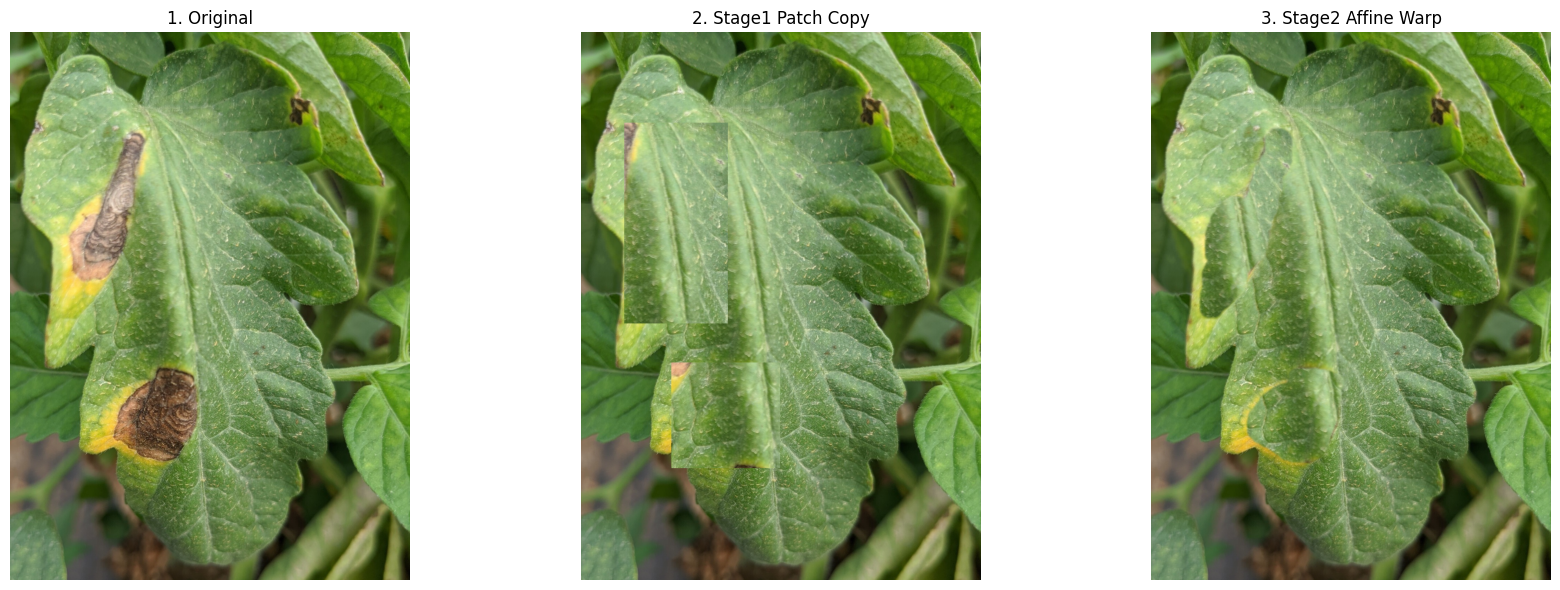

저장 완료: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_affine_restored.png


In [6]:

# =========================
# 경로
# =========================

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(BASE_DIR, "original", "Tomato Early Blight1.jpg")
MASK_PATH = os.path.join(BASE_DIR, "mask", "Tomato Early Blight1.png")

OUTPUT_DIR = os.path.join(BASE_DIR, "patch_restoration_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH = os.path.join(OUTPUT_DIR, "early_blight1_affine_restored.png")

# =========================
# 이미지 로드
# =========================

image_bgr = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

h, w = image.shape[:2]

# =========================
# connected components
# =========================

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)

restored = image.copy()
stage1 = image.copy()

MIN_AREA = 30

# =========================
# component loop
# =========================

for label_id in range(1, num_labels):

    x, y, bw, bh, area = stats[label_id]

    if area < MIN_AREA:
        continue

    pad = 16

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w, x + bw + pad)
    y2 = min(h, y + bh + pad)

    target_w = x2 - x1
    target_h = y2 - y1

    target_region = image[y1:y2, x1:x2]
    target_mask = mask_bin[y1:y2, x1:x2]

    healthy_pixels = target_region[target_mask == 0]

    if len(healthy_pixels) == 0:
        continue

    target_mean = healthy_pixels.mean(axis=0)

    # =========================
    # best patch 탐색
    # =========================

    best_score = float("inf")
    best_patch = None

    step = 10

    for yy in range(0, h - target_h, step):
        for xx in range(0, w - target_w, step):

            candidate_mask = mask_bin[yy:yy+target_h, xx:xx+target_w]

            if np.mean(candidate_mask > 0) > 0.05:
                continue

            candidate = image[yy:yy+target_h, xx:xx+target_w]

            rotations = [
                candidate,
                cv2.rotate(candidate, cv2.ROTATE_90_CLOCKWISE),
                cv2.rotate(candidate, cv2.ROTATE_180),
                cv2.rotate(candidate, cv2.ROTATE_90_COUNTERCLOCKWISE),
            ]

            for rot in rotations:

                rot = cv2.resize(rot, (target_w, target_h))

                cand_mean = rot.reshape(-1, 3).mean(axis=0)

                score = np.linalg.norm(cand_mean - target_mean)

                if score < best_score:
                    best_score = score
                    best_patch = rot.copy()

    if best_patch is None:
        continue

    # =========================
    # Stage1
    # =========================

    stage1[y1:y2, x1:x2] = best_patch

    # =========================
    # Affine Warp
    # =========================

    src_pts = np.float32([
        [0, 0],
        [target_w - 1, 0],
        [0, target_h - 1]
    ])

    dst_pts = np.float32([
        [0, 0],
        [target_w * 0.95, target_h * 0.03],
        [target_w * 0.03, target_h * 0.95]
    ])

    M = cv2.getAffineTransform(src_pts, dst_pts)

    warped_patch = cv2.warpAffine(
        best_patch,
        M,
        (target_w, target_h),
        borderMode=cv2.BORDER_REFLECT
    )

    # =========================
    # selective blending
    # =========================

    mask_float = target_mask.astype(np.float32) / 255.0
    mask_float = cv2.GaussianBlur(mask_float, (15, 15), 0)
    mask_float = np.expand_dims(mask_float, axis=-1)

    original_crop = restored[y1:y2, x1:x2]

    blended_crop = (
        warped_patch * mask_float +
        original_crop * (1.0 - mask_float)
    ).astype(np.uint8)

    restored[y1:y2, x1:x2] = blended_crop

# =========================
# 시각화
# =========================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stage1)
plt.title("2. Stage1 Patch Copy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(restored)
plt.title("3. Stage2 Affine Warp")
plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# 저장
# =========================

Image.fromarray(restored).save(SAVE_PATH)

print("저장 완료:", SAVE_PATH)

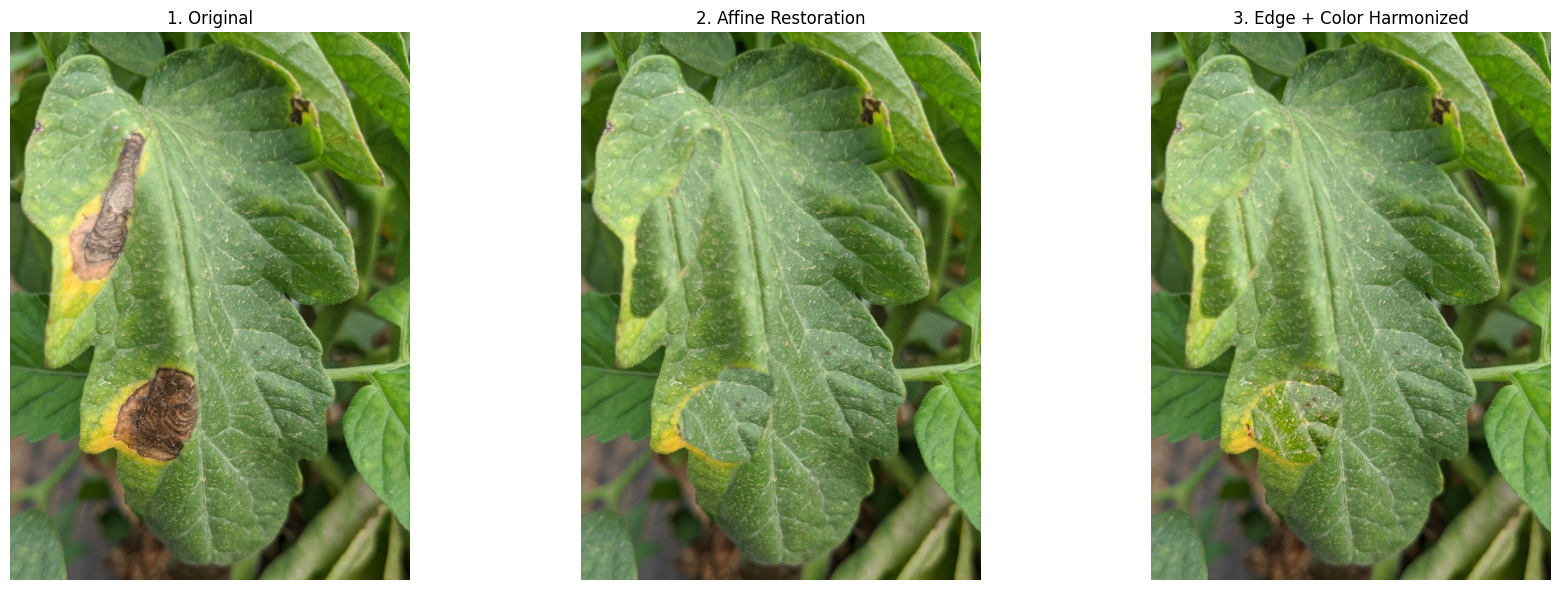

저장 완료: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/early_blight1_harmonized_restored.png


In [7]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(BASE_DIR, "original", "Tomato Early Blight1.jpg")
MASK_PATH = os.path.join(BASE_DIR, "mask", "Tomato Early Blight1.png")

OUTPUT_DIR = os.path.join(BASE_DIR, "patch_restoration_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH = os.path.join(OUTPUT_DIR, "early_blight1_harmonized_restored.png")

image_bgr = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

h, w = image.shape[:2]

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)

affine_stage = image.copy()
harmonized = image.copy()

MIN_AREA = 30

def match_color_lab(source_rgb, reference_rgb, mask_area=None):
    src_lab = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    ref_lab = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)

    if mask_area is not None:
        valid = mask_area > 0
        if valid.sum() < 10:
            return source_rgb
        src_pixels = src_lab[valid]
        ref_pixels = ref_lab[~valid] if (~valid).sum() > 10 else ref_lab.reshape(-1, 3)
    else:
        src_pixels = src_lab.reshape(-1, 3)
        ref_pixels = ref_lab.reshape(-1, 3)

    src_mean, src_std = src_pixels.mean(axis=0), src_pixels.std(axis=0) + 1e-6
    ref_mean, ref_std = ref_pixels.mean(axis=0), ref_pixels.std(axis=0) + 1e-6

    matched = (src_lab - src_mean) / src_std * ref_std + ref_mean
    matched = np.clip(matched, 0, 255).astype(np.uint8)

    return cv2.cvtColor(matched, cv2.COLOR_LAB2RGB)

for label_id in range(1, num_labels):
    x, y, bw, bh, area = stats[label_id]

    if area < MIN_AREA:
        continue

    pad = 16

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w, x + bw + pad)
    y2 = min(h, y + bh + pad)

    target_w = x2 - x1
    target_h = y2 - y1

    target_region = image[y1:y2, x1:x2]
    target_mask = mask_bin[y1:y2, x1:x2]

    healthy_pixels = target_region[target_mask == 0]
    if len(healthy_pixels) == 0:
        continue

    target_mean = healthy_pixels.mean(axis=0)

    best_score = float("inf")
    best_patch = None

    step = 10

    for yy in range(0, h - target_h, step):
        for xx in range(0, w - target_w, step):

            candidate_mask = mask_bin[yy:yy+target_h, xx:xx+target_w]
            if np.mean(candidate_mask > 0) > 0.05:
                continue

            candidate = image[yy:yy+target_h, xx:xx+target_w]

            rotations = [
                candidate,
                cv2.rotate(candidate, cv2.ROTATE_90_CLOCKWISE),
                cv2.rotate(candidate, cv2.ROTATE_180),
                cv2.rotate(candidate, cv2.ROTATE_90_COUNTERCLOCKWISE),
            ]

            for rot in rotations:
                rot = cv2.resize(rot, (target_w, target_h))

                cand_mean = rot.reshape(-1, 3).mean(axis=0)
                color_score = np.linalg.norm(cand_mean - target_mean)

                cand_gray = cv2.cvtColor(rot, cv2.COLOR_RGB2GRAY)
                target_gray = cv2.cvtColor(target_region, cv2.COLOR_RGB2GRAY)

                texture_score = abs(
                    cv2.Laplacian(cand_gray, cv2.CV_64F).var()
                    - cv2.Laplacian(target_gray, cv2.CV_64F).var()
                )

                score = color_score + 0.03 * texture_score

                if score < best_score:
                    best_score = score
                    best_patch = rot.copy()

    if best_patch is None:
        continue

    # Affine warp
    src_pts = np.float32([
        [0, 0],
        [target_w - 1, 0],
        [0, target_h - 1]
    ])

    dst_pts = np.float32([
        [0, 0],
        [target_w * 0.95, target_h * 0.03],
        [target_w * 0.03, target_h * 0.95]
    ])

    M = cv2.getAffineTransform(src_pts, dst_pts)

    warped_patch = cv2.warpAffine(
        best_patch,
        M,
        (target_w, target_h),
        borderMode=cv2.BORDER_REFLECT
    )

    # 색감 맞추기
    color_matched_patch = match_color_lab(
        warped_patch,
        target_region,
        target_mask
    )

    # 마스크 feather
    mask_float = target_mask.astype(np.float32) / 255.0
    mask_float = cv2.GaussianBlur(mask_float, (21, 21), 0)
    mask_float = np.expand_dims(mask_float, axis=-1)

    # Affine stage
    affine_crop = affine_stage[y1:y2, x1:x2]
    affine_blend = (
        warped_patch * mask_float +
        affine_crop * (1.0 - mask_float)
    ).astype(np.uint8)
    affine_stage[y1:y2, x1:x2] = affine_blend

    # Harmonized stage
    target_crop = harmonized[y1:y2, x1:x2]
    blended_crop = (
        color_matched_patch * mask_float +
        target_crop * (1.0 - mask_float)
    ).astype(np.uint8)

    # 경계 부드럽게
    edge_mask = cv2.dilate(target_mask, np.ones((5, 5), np.uint8), iterations=1)
    edge_mask = cv2.GaussianBlur(edge_mask.astype(np.float32) / 255.0, (15, 15), 0)
    edge_mask = np.expand_dims(edge_mask, axis=-1)

    smooth_crop = cv2.bilateralFilter(blended_crop, d=5, sigmaColor=30, sigmaSpace=30)

    final_crop = (
        smooth_crop * edge_mask +
        blended_crop * (1.0 - edge_mask)
    ).astype(np.uint8)

    harmonized[y1:y2, x1:x2] = final_crop

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(affine_stage)
plt.title("2. Affine Restoration")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(harmonized)
plt.title("3. Edge + Color Harmonized")
plt.axis("off")

plt.tight_layout()
plt.show()

Image.fromarray(harmonized).save(SAVE_PATH)
print("저장 완료:", SAVE_PATH)

In [9]:
import os
from PIL import Image
from tqdm import tqdm

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting/lora_dataset"

HEALTHY_DIR = os.path.join(BASE_DIR, "Tomato___healthy")
CROP_DIR = os.path.join(BASE_DIR, "lora_train_crops", "Tomato___healthy")

os.makedirs(CROP_DIR, exist_ok=True)

IMG_SIZE = 1024
MAX_CROPS_PER_IMAGE = 3

valid_exts = [".jpg", ".jpeg", ".png", ".webp"]

image_files = [
    f for f in os.listdir(HEALTHY_DIR)
    if os.path.splitext(f.lower())[1] in valid_exts
]

print("원본 건강 잎 이미지 수:", len(image_files))
print("crop 저장 경로:", CROP_DIR)

def center_square_crop(img):
    w, h = img.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    return img.crop((left, top, left + side, top + side))

save_count = 0

for fname in tqdm(image_files):
    path = os.path.join(HEALTHY_DIR, fname)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("로드 실패:", path)
        continue

    w, h = img.size
    side = min(w, h)

    crop_boxes = []

    # center crop
    left = (w - side) // 2
    top = (h - side) // 2
    crop_boxes.append((left, top, left + side, top + side))

    # 약간 좌상단/우하단 variation
    if MAX_CROPS_PER_IMAGE >= 2:
        crop_boxes.append((0, 0, side, side))

    if MAX_CROPS_PER_IMAGE >= 3:
        crop_boxes.append((w - side, h - side, w, h))

    for i, box in enumerate(crop_boxes[:MAX_CROPS_PER_IMAGE]):
        crop = img.crop(box)
        crop = crop.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

        save_name = f"{os.path.splitext(fname)[0]}_crop{i+1}.png"
        save_path = os.path.join(CROP_DIR, save_name)

        crop.save(save_path)
        save_count += 1

print("생성된 crop 수:", save_count)

원본 건강 잎 이미지 수: 62
crop 저장 경로: /home/harry/Re_leaf_Project/Inpainting/lora_dataset/lora_train_crops/Tomato___healthy


100%|███████████████████████████████████████████████████████████████████████████████████| 62/62 [00:54<00:00,  1.14it/s]

생성된 crop 수: 186


In [11]:

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting/lora_dataset"

CROP_DIR = os.path.join(BASE_DIR, "lora_train_crops", "Tomato___healthy")

caption = "healthy tomato leaf, natural green leaf texture, realistic leaf veins, photorealistic plant leaf"

image_exts = [".jpg", ".jpeg", ".png", ".webp"]

image_files = [
    f for f in os.listdir(CROP_DIR)
    if os.path.splitext(f.lower())[1] in image_exts
]

print("caption 생성 대상:", len(image_files))

for fname in tqdm(image_files):
    txt_name = os.path.splitext(fname)[0] + ".txt"
    txt_path = os.path.join(CROP_DIR, txt_name)

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(caption)

print("caption 생성 완료")

caption 생성 대상: 186


100%|██████████████████████████████████████████████████████████████████████████████| 186/186 [00:00<00:00, 24275.46it/s]

caption 생성 완료


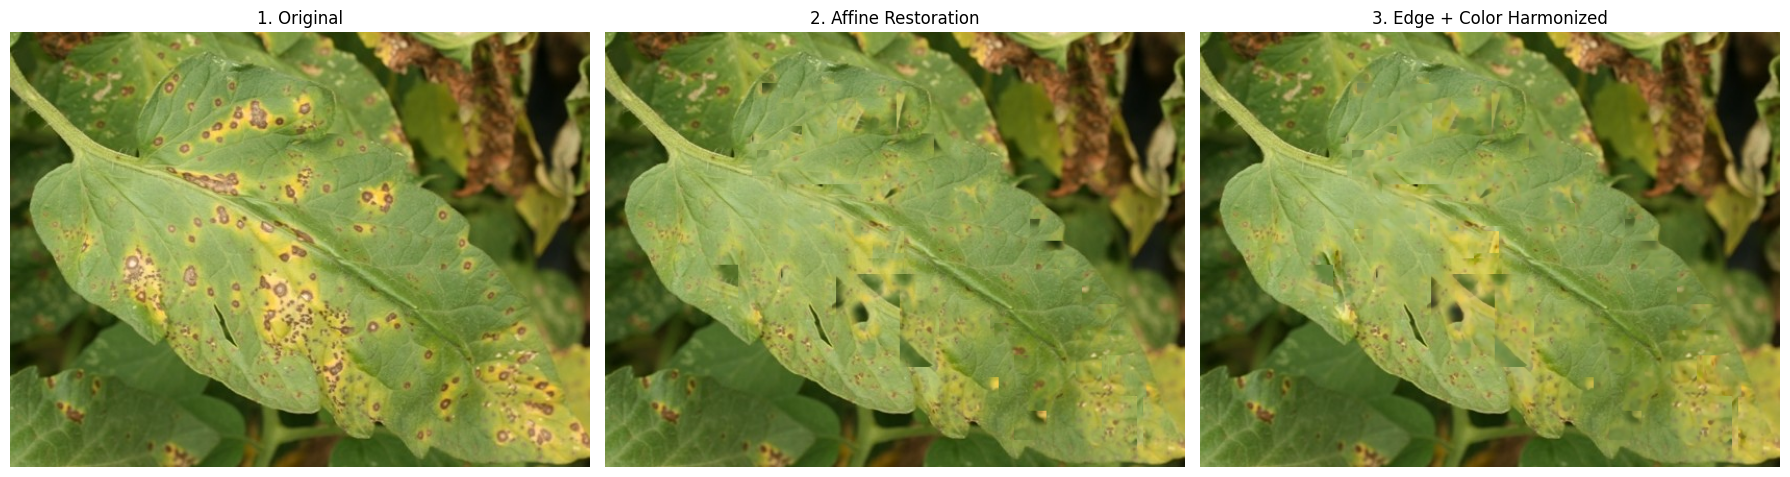

저장 완료: /home/harry/Re_leaf_Project/Inpainting/patch_restoration_output/septoria1_harmonized_restored.png


In [1]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(BASE_DIR, "original", "Tomato Septoria1.jpg")
MASK_PATH = os.path.join(BASE_DIR, "mask", "Tomato Septoria1.png")

OUTPUT_DIR = os.path.join(BASE_DIR, "patch_restoration_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH = os.path.join(OUTPUT_DIR, "septoria1_harmonized_restored.png")

image_bgr = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

h, w = image.shape[:2]

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)

affine_stage = image.copy()
harmonized = image.copy()

MIN_AREA = 30

def match_color_lab(source_rgb, reference_rgb, mask_area=None):
    src_lab = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    ref_lab = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)

    if mask_area is not None:
        valid = mask_area > 0
        if valid.sum() < 10:
            return source_rgb
        src_pixels = src_lab[valid]
        ref_pixels = ref_lab[~valid] if (~valid).sum() > 10 else ref_lab.reshape(-1, 3)
    else:
        src_pixels = src_lab.reshape(-1, 3)
        ref_pixels = ref_lab.reshape(-1, 3)

    src_mean, src_std = src_pixels.mean(axis=0), src_pixels.std(axis=0) + 1e-6
    ref_mean, ref_std = ref_pixels.mean(axis=0), ref_pixels.std(axis=0) + 1e-6

    matched = (src_lab - src_mean) / src_std * ref_std + ref_mean
    matched = np.clip(matched, 0, 255).astype(np.uint8)

    return cv2.cvtColor(matched, cv2.COLOR_LAB2RGB)

for label_id in range(1, num_labels):
    x, y, bw, bh, area = stats[label_id]

    if area < MIN_AREA:
        continue

    pad = 16

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w, x + bw + pad)
    y2 = min(h, y + bh + pad)

    target_w = x2 - x1
    target_h = y2 - y1

    target_region = image[y1:y2, x1:x2]
    target_mask = mask_bin[y1:y2, x1:x2]

    healthy_pixels = target_region[target_mask == 0]
    if len(healthy_pixels) == 0:
        continue

    target_mean = healthy_pixels.mean(axis=0)

    best_score = float("inf")
    best_patch = None

    step = 10

    for yy in range(0, h - target_h, step):
        for xx in range(0, w - target_w, step):

            candidate_mask = mask_bin[yy:yy+target_h, xx:xx+target_w]
            if np.mean(candidate_mask > 0) > 0.05:
                continue

            candidate = image[yy:yy+target_h, xx:xx+target_w]

            rotations = [
                candidate,
                cv2.rotate(candidate, cv2.ROTATE_90_CLOCKWISE),
                cv2.rotate(candidate, cv2.ROTATE_180),
                cv2.rotate(candidate, cv2.ROTATE_90_COUNTERCLOCKWISE),
            ]

            for rot in rotations:
                rot = cv2.resize(rot, (target_w, target_h))

                cand_mean = rot.reshape(-1, 3).mean(axis=0)
                color_score = np.linalg.norm(cand_mean - target_mean)

                cand_gray = cv2.cvtColor(rot, cv2.COLOR_RGB2GRAY)
                target_gray = cv2.cvtColor(target_region, cv2.COLOR_RGB2GRAY)

                texture_score = abs(
                    cv2.Laplacian(cand_gray, cv2.CV_64F).var()
                    - cv2.Laplacian(target_gray, cv2.CV_64F).var()
                )

                score = color_score + 0.03 * texture_score

                if score < best_score:
                    best_score = score
                    best_patch = rot.copy()

    if best_patch is None:
        continue

    # Affine warp
    src_pts = np.float32([
        [0, 0],
        [target_w - 1, 0],
        [0, target_h - 1]
    ])

    dst_pts = np.float32([
        [0, 0],
        [target_w * 0.95, target_h * 0.03],
        [target_w * 0.03, target_h * 0.95]
    ])

    M = cv2.getAffineTransform(src_pts, dst_pts)

    warped_patch = cv2.warpAffine(
        best_patch,
        M,
        (target_w, target_h),
        borderMode=cv2.BORDER_REFLECT
    )

    # 색감 맞추기
    color_matched_patch = match_color_lab(
        warped_patch,
        target_region,
        target_mask
    )

    # 마스크 feather
    mask_float = target_mask.astype(np.float32) / 255.0
    mask_float = cv2.GaussianBlur(mask_float, (21, 21), 0)
    mask_float = np.expand_dims(mask_float, axis=-1)

    # Affine stage
    affine_crop = affine_stage[y1:y2, x1:x2]
    affine_blend = (
        warped_patch * mask_float +
        affine_crop * (1.0 - mask_float)
    ).astype(np.uint8)
    affine_stage[y1:y2, x1:x2] = affine_blend

    # Harmonized stage
    target_crop = harmonized[y1:y2, x1:x2]
    blended_crop = (
        color_matched_patch * mask_float +
        target_crop * (1.0 - mask_float)
    ).astype(np.uint8)

    # 경계 부드럽게
    edge_mask = cv2.dilate(target_mask, np.ones((5, 5), np.uint8), iterations=1)
    edge_mask = cv2.GaussianBlur(edge_mask.astype(np.float32) / 255.0, (15, 15), 0)
    edge_mask = np.expand_dims(edge_mask, axis=-1)

    smooth_crop = cv2.bilateralFilter(blended_crop, d=5, sigmaColor=30, sigmaSpace=30)

    final_crop = (
        smooth_crop * edge_mask +
        blended_crop * (1.0 - edge_mask)
    ).astype(np.uint8)

    harmonized[y1:y2, x1:x2] = final_crop

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(affine_stage)
plt.title("2. Affine Restoration")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(harmonized)
plt.title("3. Edge + Color Harmonized")
plt.axis("off")

plt.tight_layout()
plt.show()

Image.fromarray(harmonized).save(SAVE_PATH)
print("저장 완료:", SAVE_PATH)